In [46]:
import pandas as pd
import numpy as np
from functions import cat
from functions import rotate
from functions import flip
from functions import visualize_matrix
from functions import shift

In [58]:
df1 = pd.read_csv(r"data\1_12_merged.csv", sep=";")
df2 = pd.read_csv(r"data\merge.csv", sep=";")
df3 = pd.read_csv(r"data\merge_with_Box_info.csv", sep=";")
df3 = df3[df3['KUSI'].str.contains('!!! NoUSIAxiom') == False]

data_corr = pd.DataFrame()

data_corr = data_corr.assign(**df3[['KUSI', 'code_position', 'Position', 'Box', 'PEDSEX', 'SNPSEX']])
#data_corr = data_corr.assign(**df1[['USI', 'Position', 'Box']])
#data_corr = data_corr.assign(**df2[['PEDSEX', 'SNPSEX']])

#print(data_corr)

In [3]:
# Populate the new dataframe with the existing PEDSEX and SNPSEX data to match each USI
no_matches = 0

for i in range(len(data_corr['USI'])):
    value = data_corr.loc[i, 'USI']

    if value in df2['IID'].values:
        value2 = df2.loc[df2['IID'] == value,'PEDSEX'].values[0]
        value3 = df2.loc[df2['IID'] == value,'SNPSEX'].values[0]

        data_corr.loc[i, 'PEDSEX'] = value2
        data_corr.loc[i, 'SNPSEX'] = value3

    else:
        #print("no match for " + value)
        data_corr.loc[i, 'PEDSEX'] = 0
        data_corr.loc[i, 'SNPSEX'] = 0
        no_matches += 1

#print(data_corr)
#print("number of missed matches: " + str(no_matches))

Visualization of the data

In [84]:
# Prepare new matrix

# Define factors for comparison

fac1 = 'Case'
fac2 = 'PEDSEX'
fac3 = 'SNPSEX'

fac = fac3


dim =  pd.DataFrame()

dim['Letter'] = data_corr['code_position'].str[0]
dim['Number'] = data_corr['code_position'].str[1:].astype(int)


letters = dim['Letter'].unique()
numbers= sorted(dim['Number'].unique())

subcols = [fac, 'code_position']
multi_cols = pd.MultiIndex.from_product([numbers, subcols], names=['Number', 'Field'])

matrix = pd.DataFrame(index=letters, columns=multi_cols)



# Define conditions

box_number = 7
box_curr = data_corr.loc[data_corr['Box'] == box_number].copy()
box_curr['Case']=0


# Fill 'Case'

for i in range(len(box_curr['Case'])):
    ped = box_curr.iloc[i]['PEDSEX']
    snp = box_curr.iloc[i]['SNPSEX']
    box_curr.iloc[i, box_curr.columns.get_loc('Case')] = cat(ped, snp)



In [85]:
# Populate new matrix

dim = dim.reset_index(drop=True)

for i in range(len(dim)):
    letter = dim.loc[i, 'Letter']
    number = dim.loc[i, 'Number']
    pos_str = f"{letter}{int(number):02d}"


    match = box_curr.loc[box_curr['code_position'] == pos_str, fac]
    pos = box_curr.loc[box_curr['code_position'] == pos_str, 'code_position']

    if not match.empty:
        matrix.loc[letter, (number, fac)] = match.values[0]
        matrix.loc[letter, (number, 'code_position')] = pos.values[0]
    else:
        matrix.loc[letter, (number, fac)] = None
        matrix.loc[letter, (number, 'code_position')] = None

Flip/Rotate: Add an additional dimension to the matrix showing the matches, that contains the positions. Then the correct value to visualize can be chosen as different versions via an alternate matrix_array, indicated as a different dimension in values[]. The same transformation that has been carried out on the match grid, can also be done on the positions grid.

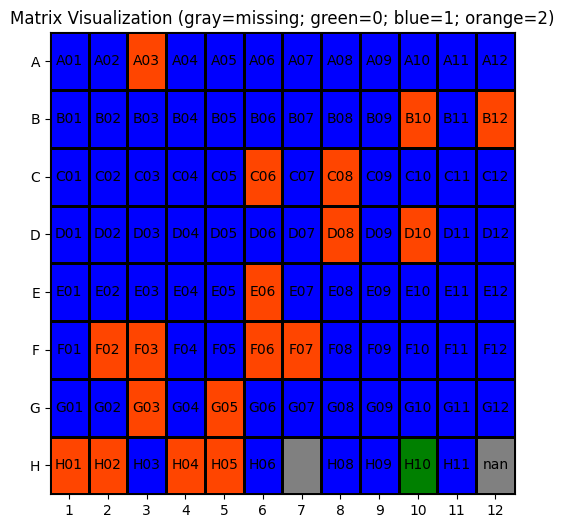

In [61]:
title="Matrix Visualization (gray=missing; green=0; blue=1; orange=2)"

m = visualize_matrix(matrix, title, fac)

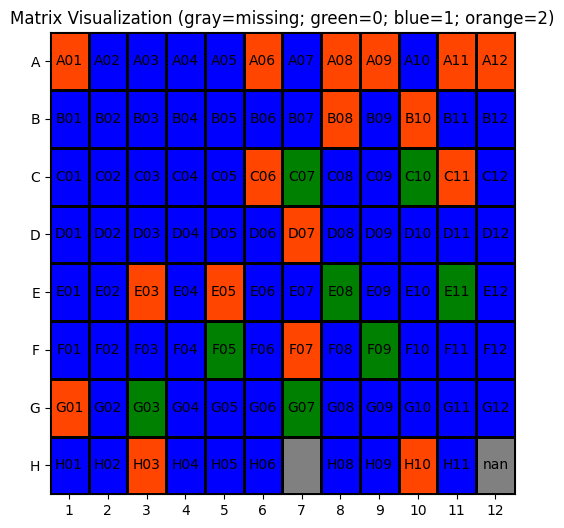

In [94]:
title="Matrix Visualization (gray=missing; green=0; blue=1; orange=2)"

m = visualize_matrix(matrix, title, fac)

In [150]:
matrix = flip(matrix, fac)

In [93]:
matrix = rotate(matrix, fac)

In [74]:
matrix = shift(matrix, fac)

Insert the corrected matrix back into the dataframe by adjusting the orders of the pre-test entries

In [90]:
df4 = pd.read_csv(r"data\merge_with_Box_info.csv", sep=";")

copy_df = df4.copy()

In [91]:
# order the data according to Box & code_position

df_sorted = copy_df.sort_values(
    by=['Box', 'code_position'],
    key=lambda col: col if col.name == 'Box' else (
        col.fillna('ZZZ999')
           .str.extract(r'([a-zA-Z]+)(\d+)')
           .astype({1: int})
           .apply(lambda x: (x[0], x[1]), axis=1)
    )
)


In [92]:
# flatten the matrix to serve as index for the new dataframe

pos = matrix.xs('code_position', axis=1, level=1)
flat = pos.values.flatten()
flat = flat[~pd.isna(flat)]

# after rotation
flat = np.insert(flat[:-1], 0, flat[-1])

# only for box 7
entry = flat[-5]
flat = np.delete(flat, -5)
flat = np.insert(flat, 5, entry)


In [93]:
df_sorted['new_positions'] = 0
df_sorted['new_positions'] = df_sorted['new_positions'].astype(object)

df_sorted.loc[df_sorted['Box'] == 7, 'new_positions'] = flat

In [94]:
# reorder

cols_update = ['IID', 'SNPSEX', 'Position']
cond = df_sorted['Box'] == 7

df_sorted.loc[cond, cols_update] = df_sorted.loc[cond, cols_update].set_index(df_sorted.loc[cond, 'code_position']).reindex(df_sorted.loc[cond, 'new_positions']).reset_index()[cols_update].values


In [95]:
df_sorted.to_csv('outputBox7.csv', sep=";", index=False)

This part for after the PEDSEX matrix has been run again

In [148]:
pos = matrix.xs('code_position', axis=1, level=1)
flat = pos.values.flatten()
flat = flat[~pd.isna(flat)]

In [149]:
df_sorted['new_positionsBox2'] = 0
df_sorted['new_positionsBox2'] = df_sorted['new_positions'].astype(object)

df_sorted.loc[df_sorted['Box'] == 2, 'new_positionsBox2'] = flat

In [ ]:
# bring back into original order, after already having aligned PEDSEX & SNPSEX

cols_update = ['IID', 'PEDSEX', 'SNPSEX', 'code_position', 'Position', 'new_positionsBox2']
cond = df_sorted['Box'] == 2

df_sorted.loc[cond, cols_update] = df_sorted.loc[cond, cols_update].set_index(df_sorted.loc[cond, 'code_position']).reindex(df_sorted.loc[cond, 'new_positionsBox2']).reset_index()[cols_update].values

In [135]:
df_sorted.to_csv('output2Box7.csv', sep=";", index=False)

Read the FAM-file and reorder the cols_update by the indices inside the new file

In [ ]:
df5 = pd.read_csv(r"final_test_fam.csv", sep=";")
pre_c = df5[df5['IID'] != 'Axiom'].copy()

df6 = pd.read_csv(r"data\affi_GSA-merge.fam", sep=r"\t")
df7 = pd.read_csv('output2Box6.csv', sep=";")
df8 = pd.read_csv('output2Box7.csv', sep=";")

fam = df6.iloc[29:].reset_index(drop=True).copy()
fam1 = df7.copy()
fam2 = df8.copy()

In [ ]:
# check if all IDs in the fam file are also in our dataset

check_IDs = fam['Axiom'].isin(pre_c['IID'])

print(check_IDs)

all_exist = check_IDs.all()
print("All entries exist in pre_c:", all_exist)

In [8]:
# transfer Box 6 into the new file

pre_c['new_positionsBox6'] = fam1['new_positionsBox6']
pre_c.loc[pre_c['Box'] == 6, ['IID', 'PEDSEX', 'SNPSEX', 'code_position', 'Position']] = \
    fam1.loc[fam1['Box'] == 6, ['IID', 'PEDSEX', 'SNPSEX', 'code_position', 'Position']].values

In [9]:
# transfer Box 7 into the new file

pre_c['new_positionsBox7'] = fam2['new_positionsBox7']
pre_c.loc[pre_c['Box'] == 7, ['IID', 'PEDSEX', 'SNPSEX', 'code_position', 'Position']] = \
    fam1.loc[fam1['Box'] == 7, ['IID', 'PEDSEX', 'SNPSEX', 'code_position', 'Position']].values

In [186]:
# reorder according to FAM-file

cols_update = ['IID','PEDSEX', 'SNPSEX', 'code_position', 'Position', 'new_positions2', 'new_positionsBox6', 'new_positionsBox7', 'Box']

pre_c.loc[:, cols_update] = (
    pre_c.loc[:, cols_update]
    .set_index(pre_c['IID'])
    .reindex(fam.loc[:, 'Axiom'])
    .reset_index()[cols_update]
    .values
)

final_df = pre_c.copy()

In [187]:
final_df.to_csv('final_test_fam.csv', sep=";", index=False)

Output new FAM-file

In [4]:
nf = pd.read_csv(r"final_test_fam.csv", sep=";")

new_fam = pd.DataFrame(index=nf.index, columns=range(6))
# new_fam.iloc[:, 0] = range(1, len(new_fam) + 1)
new_fam.iloc[:, 0] = nf['IID']
new_fam.iloc[:, 1] = nf['IID']
new_fam.iloc[:, 4] = nf['PEDSEX']
new_fam.iloc[:, [2, 3, 5]] = 0

In [7]:
new_fam.to_csv('phantomFAM.txt', sep='\t', index=False, header=False)

Check FAM files

In [ ]:
origin = pd.read_csv(r"data\test_FS.fam", sep="\s", header=None)

In [28]:
replace = pd.read_csv(r"data\PG_test_FS.fam", sep="\t", header=None)

In [ ]:
# Check if all elements inside the first dataframe are inside the second

origin_col = origin.iloc[:, 0].astype(str).fillna('')
replace_col = replace.iloc[:, 0].astype(str).fillna('')

missing = []

for i, o in origin_col.items():
    if not replace_col.apply(lambda r: r.lower() in o.lower()).any():
        missing.append((i, o))

if missing:
    print(f"{len(missing)} entries from 'origin' have no match in 'replace':")
    for m in missing:
        print(m)
else:
    print("All entries from 'origin' have at least one match in 'replace'.")

In [ ]:
# Reorder second dataframe according to first; add missing elements

origin_col = origin.iloc[:, 0].astype(str).fillna('')
replace_col = replace.iloc[:, 0].astype(str).fillna('')

new_replace_rows = []

for o in origin_col:
    matches = replace[replace_col.apply(lambda r: r.lower() in o.lower())]

    if not matches.empty:
        new_replace_rows.append(matches.iloc[0])
    else:
        new_row = [o] + [0] * (replace.shape[1] - 1)
        new_replace_rows.append(pd.Series(new_row, index=replace.columns))

reordered_replace = pd.DataFrame(new_replace_rows).reset_index(drop=True)

print("Reordered 'replace':")
print(reordered_replace)

In [57]:
reordered_replace.to_csv('phantomFAMcorr.txt', sep=' ', index=False, header=False)

Fix Box 7

In [ ]:
df_corr7 = pd.read_csv('output2Box7.csv', sep=";")
df_corr2 = pd.read_csv('output2.csv', sep=";")
df_corr6 = pd.read_csv('output2Box6.csv', sep=";")

re_re = pd.read_csv("data\PG_test_FS.fam", sep=" ", header=None)

In [178]:
df_corr = df_corr7[df_corr7['Box'] == 7]

In [179]:
df_corr_filtered = df_corr[~df_corr['IID'].str.contains('Axiom', na=False)]

mapping = df_corr_filtered.set_index('IID')['PEDSEX']

re_re[4] = re_re[0].map(mapping).combine_first(re_re[4])


In [180]:
re_re[re_re.select_dtypes('float').columns] = re_re.select_dtypes('float').astype(int)

In [181]:
#print(re_re)
re_re.to_csv('phantomFAMcorr4.txt', sep=' ', index=False, header=False)